-- Dataset Summary ---
Dimensions: (1372, 5)
Missing Values: 
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


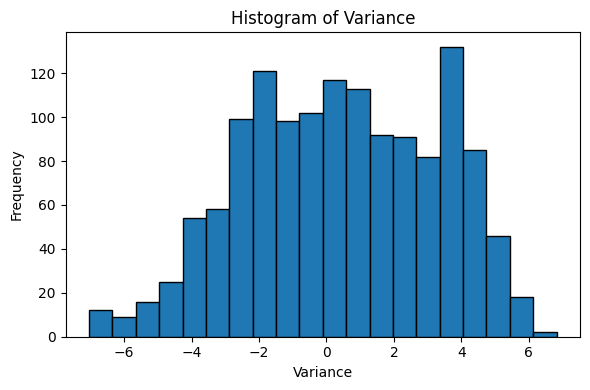

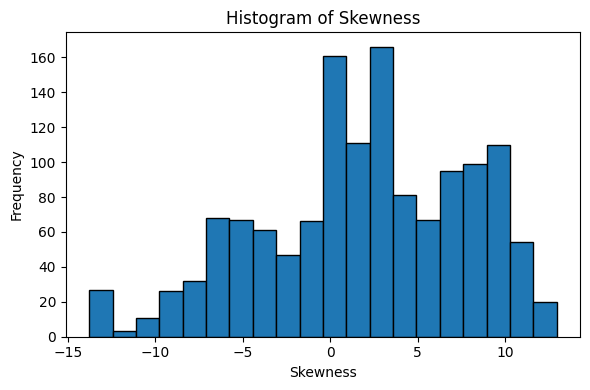

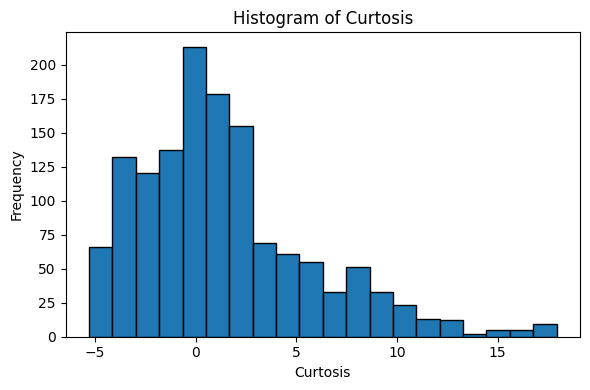

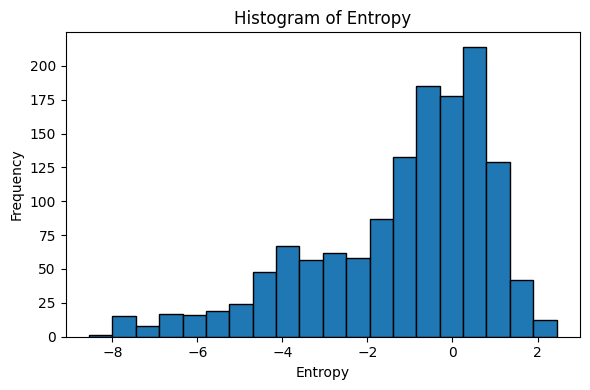

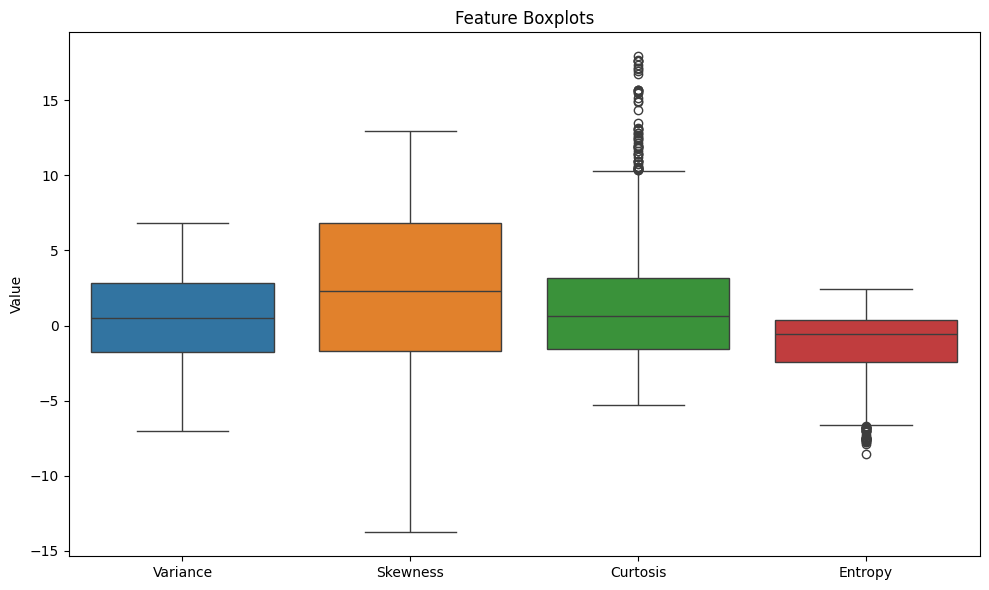

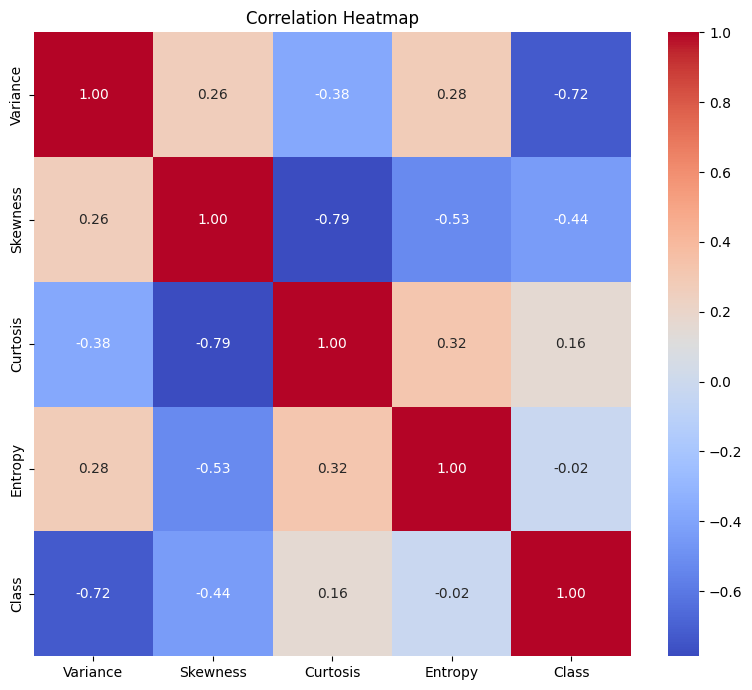

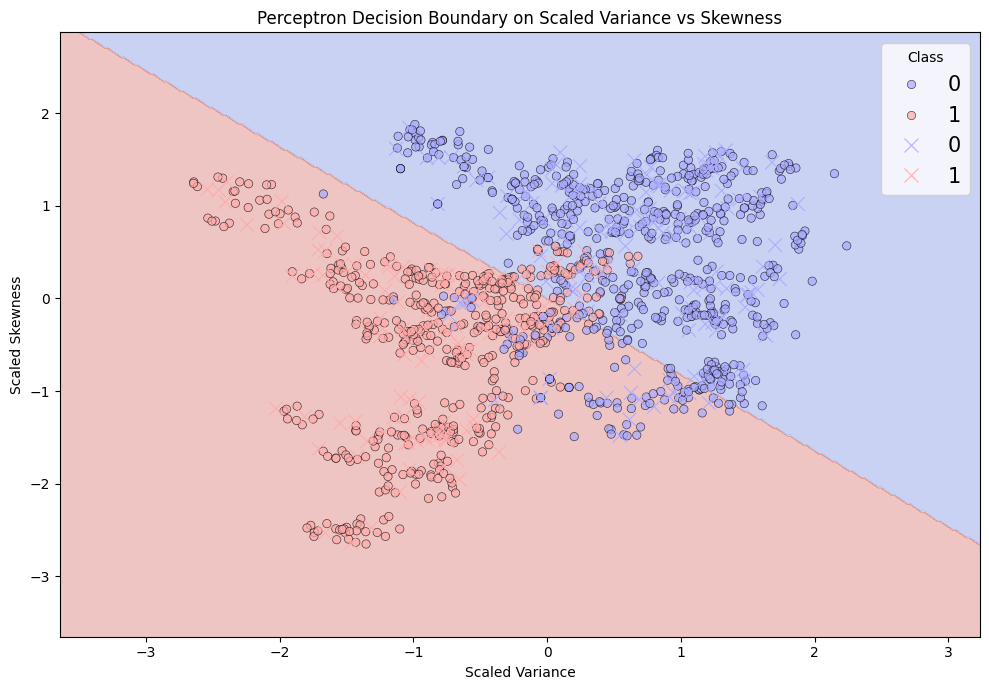


--- Performance Metrics ---
Accuracy:  0.9855
Precision: 0.9683
Recall:    1.0000
F1-score:  0.9839


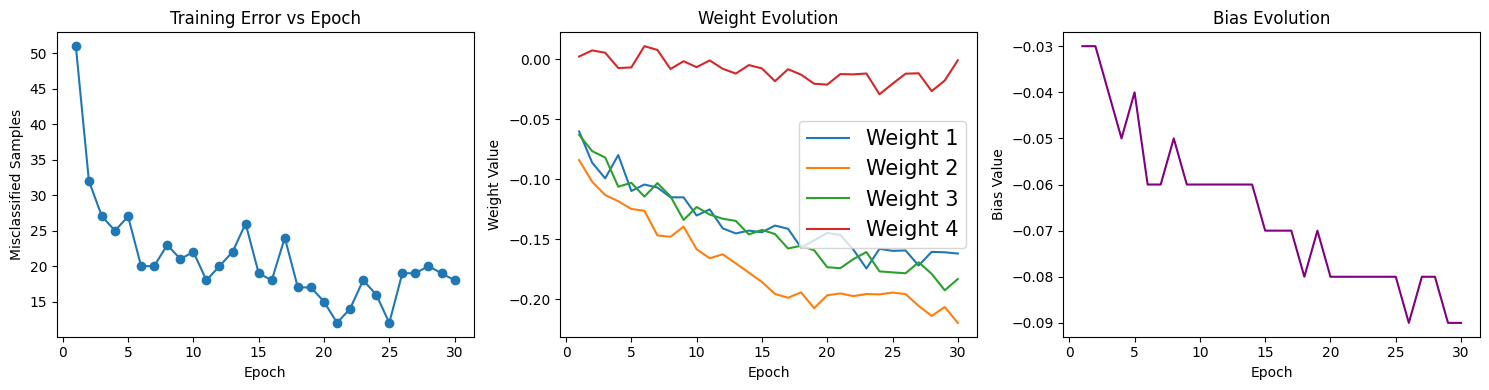

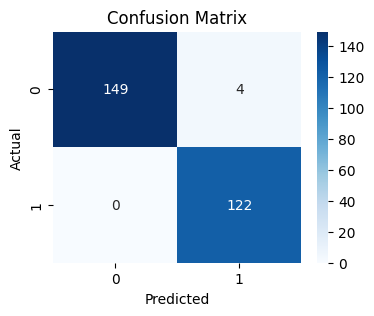

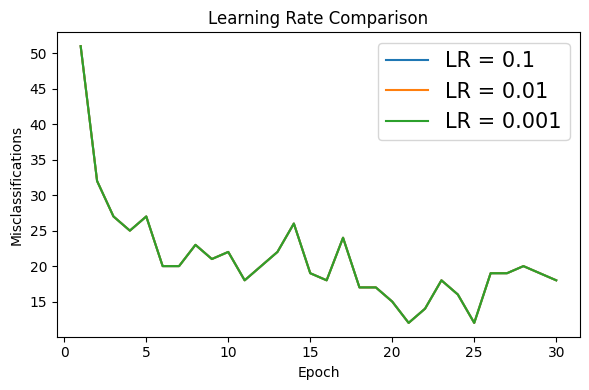


Scikit-learn Perceptron Accuracy: 0.9673


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import Perceptron as SklearnPerceptron


#Task 1 Dataset Exploration
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
cols = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]
df = pd.read_csv(url, names=cols)

print("-- Dataset Summary ---")
print(f"Dimensions: {df.shape}")
print(f"Missing Values: \n{df.isnull().sum()}\n")
print(df.describe())


# Task 2 Exploratory Data Analysis (EDA)

plt.rcParams['legend.fontsize'] = 15

# 1 Histograms
features_to_plot = df.drop('Class', axis=1).columns
for i, feature in enumerate(features_to_plot):
    plt.figure(figsize=(6, 4))
    df[feature].hist(bins=20, edgecolor='black')
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(f'histogram_{feature}.eps', format='eps', dpi=600)
    plt.savefig(f'histogram_{feature}.png', format='png', dpi=600)
    plt.show()

# 2 Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop('Class', axis=1))
plt.title("Feature Boxplots")
plt.ylabel('Value')
plt.grid(False)
plt.tight_layout()
plt.savefig('feature_boxplots.eps', format='eps', dpi=600)
plt.savefig('feature_boxplots.png', format='png', dpi=600)
plt.show()

# 3 Correlation Heatmap (remains in a single plot for clarity)
plt.figure(figsize=(8, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.grid(False)
plt.tight_layout()
plt.savefig('correlation_heatmap.eps', format='eps', dpi=600)
plt.savefig('correlation_heatmap.png', format='png', dpi=600)
plt.show()




#Task 3 Data Preprocessing
X = df.drop('Class', axis=1).values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Task 4 & 5: Perceptron Implementation
class SingleLayerPerceptron:
    def __init__(self, learning_rate=0.01, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

        # History for plotting
        self.error_history = []
        self.weight_history = []
        self.bias_history = []

    def activation_fn(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            errors = 0
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_pred = self.activation_fn(linear_output)

                update = self.lr * (y[idx] - y_pred)
                self.weights += update * x_i
                self.bias += update

                if update != 0.0:
                    errors += 1

            self.error_history.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation_fn(linear_output)

X_train_2d = X_train_scaled[:, :2]
X_test_2d = X_test_scaled[:, :2]

# Train a new Perceptron model on only these two features
model_2d = SingleLayerPerceptron(learning_rate=0.01, epochs=30)
model_2d.fit(X_train_2d, y_train)

# Create a meshgrid to plot the decision boundary
x_min, x_max = np.concatenate((X_train_2d[:, 0], X_test_2d[:, 0])).min() - 1, np.concatenate((X_train_2d[:, 0], X_test_2d[:, 0])).max() + 1
y_min, y_max = np.concatenate((X_train_2d[:, 1], X_test_2d[:, 1])).min() - 1, np.concatenate((X_train_2d[:, 1], X_test_2d[:, 1])).max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class for each point in the meshgrid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Plot the training points
sns.scatterplot(x=X_train_2d[:, 0], y=X_train_2d[:, 1], hue=y_train,
                palette='bwr', alpha=0.7, edgecolor='k', legend='full')

# Plot the test points
sns.scatterplot(x=X_test_2d[:, 0], y=X_test_2d[:, 1], hue=y_test,
                palette='bwr', alpha=0.9, marker='x', s=100, legend='full')

plt.title('Perceptron Decision Boundary on Scaled Variance vs Skewness')
plt.xlabel('Scaled Variance')
plt.ylabel('Scaled Skewness')
plt.grid(False)
plt.legend(title='Class')
plt.tight_layout()
plt.savefig('perceptron_decision_boundary.eps', format='eps', dpi=600) # Save decision boundary plot as EPS
plt.savefig('perceptron_decision_boundary.png', format='png', dpi=600) # Save decision boundary plot as PNG
plt.show()



# Train the model
model = SingleLayerPerceptron(learning_rate=0.01, epochs=30)
model.fit(X_train_scaled, y_train)

# Task 6: Model Evaluation & Plots
y_pred = model.predict(X_test_scaled)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Performance Metrics ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Plotting Training Dynamics
plt.figure(figsize=(15, 4))

# 1. Training Error vs Epoch
plt.subplot(1, 3, 1)
plt.plot(range(1, model.epochs + 1), model.error_history, marker='o')
plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.grid(False)

# 2. Weight Evolution
weight_history_np = np.array(model.weight_history)
plt.subplot(1, 3, 2)
for i in range(weight_history_np.shape[1]):
    plt.plot(range(1, model.epochs + 1), weight_history_np[:, i], label=f'Weight {i+1}')
plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(False)

# 3. Bias Evolution
plt.subplot(1, 3, 3)
plt.plot(range(1, model.epochs + 1), model.bias_history, color='purple')
plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.grid(False)

plt.tight_layout()
plt.savefig('training_dynamics.eps', format='eps', dpi=600)
plt.savefig('training_dynamics.png', format='png', dpi=600)
plt.show()

# Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.grid(False)
plt.savefig('confusion_matrix.eps', format='eps', dpi=600)
plt.savefig('confusion_matrix.png', format='png', dpi=600)
plt.show()

# Additional Task: Learning Rate Comparison

learning_rates = [0.1, 0.01, 0.001]
plt.figure(figsize=(6, 4))

for lr in learning_rates:
    temp_model = SingleLayerPerceptron(learning_rate=lr, epochs=30)
    temp_model.fit(X_train_scaled, y_train)
    plt.plot(range(1, 31), temp_model.error_history, label=f'LR = {lr}')

plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassifications")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig('learning_rate_comparison.eps', format='eps', dpi=600)
plt.savefig('learning_rate_comparison.png', format='png', dpi=600)
plt.show()


# Additional Task: Scikit-learn Comparison

sk_model = SklearnPerceptron(eta0=0.01, max_iter=30, random_state=42)
sk_model.fit(X_train_scaled, y_train)
sk_pred = sk_model.predict(X_test_scaled)
print(f"\nScikit-learn Perceptron Accuracy: {accuracy_score(y_test, sk_pred):.4f}")

# Additional Exercise-1
 Code the perceptron learning algorithm for OR, NOT, and AND gates using Python. Show the weights after each update. Plot the decision boundary after each weight update using Python built-in packages. (K4)


========== NOT Gate ==========
Update 1: w=-1.0, b=-1.0
Update 2: w=-1.0, b=0.0
Converged in 3 epochs.
Saved plot to NOT_gate.eps


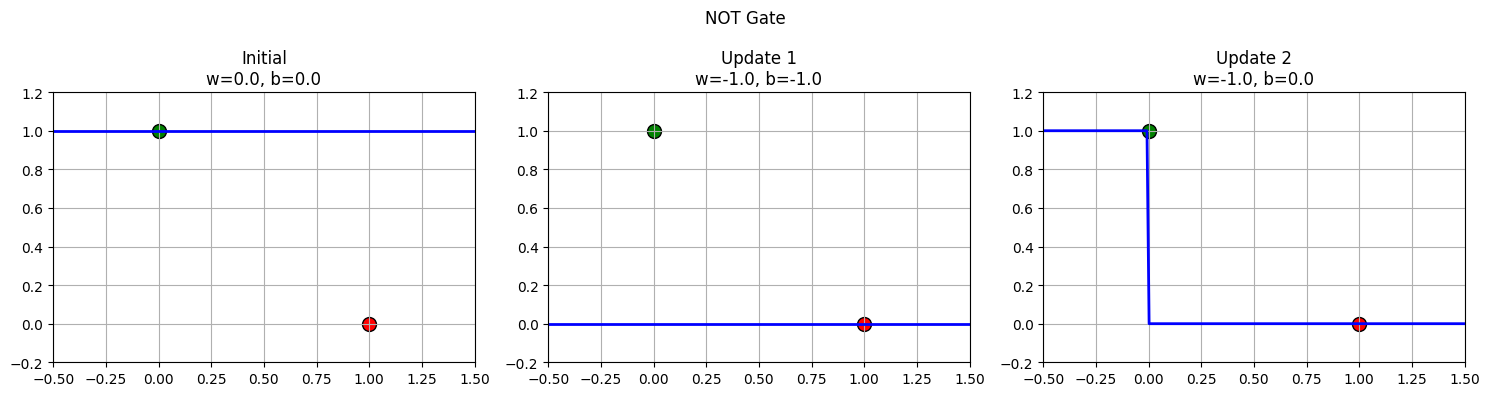


========== OR Gate ==========
Update 1: w1=0.0, w2=0.0, b=-1.0
Update 2: w1=0.0, w2=1.0, b=0.0
Update 3: w1=0.0, w2=1.0, b=-1.0
Update 4: w1=1.0, w2=1.0, b=0.0
Update 5: w1=1.0, w2=1.0, b=-1.0
Converged in 4 epochs.


Saved plot to OR_gate.eps


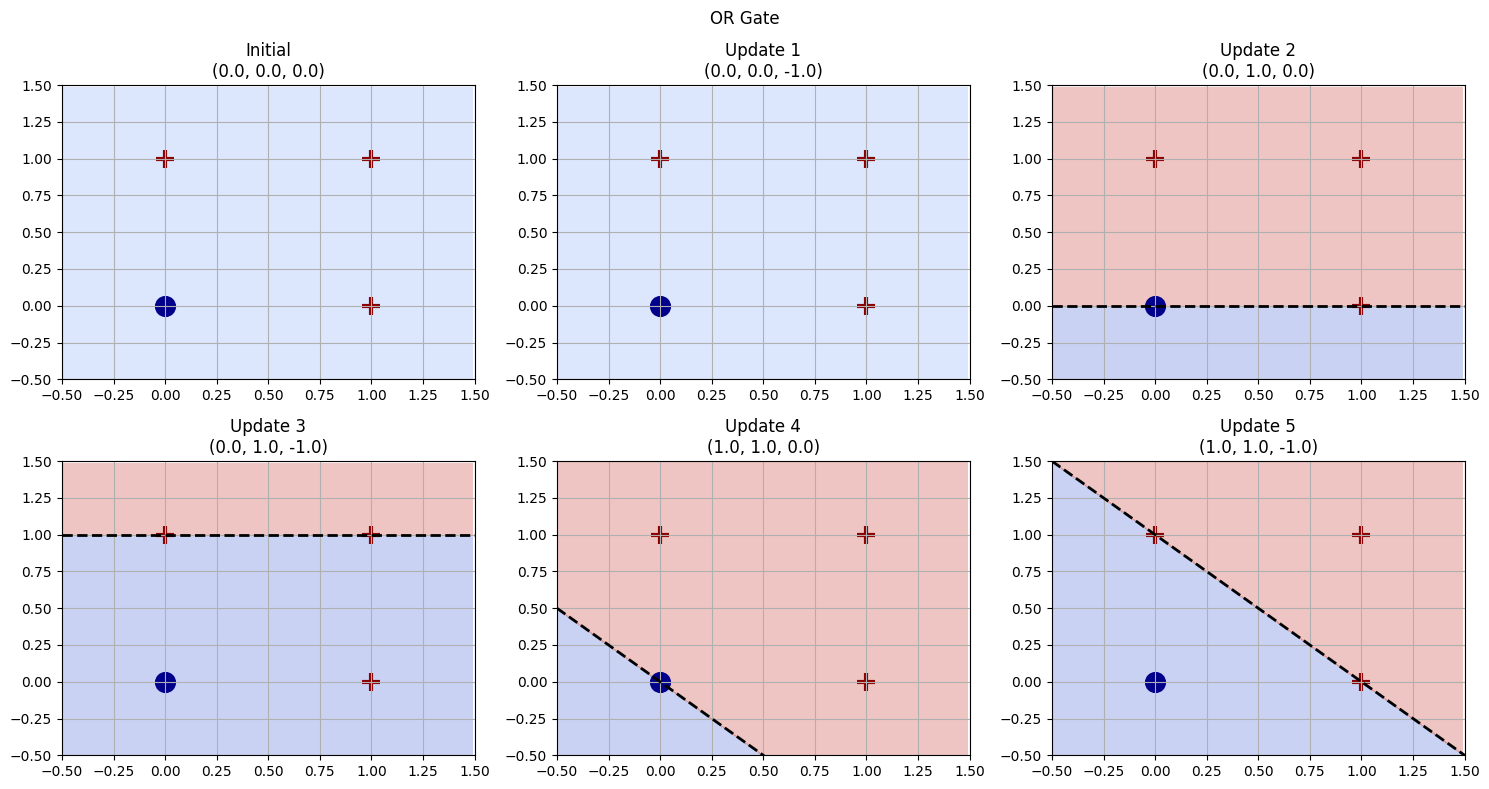


========== AND Gate ==========
Update 1: w1=0.0, w2=0.0, b=-1.0
Update 2: w1=1.0, w2=1.0, b=0.0
Update 3: w1=1.0, w2=1.0, b=-1.0
Update 4: w1=1.0, w2=0.0, b=-2.0
Update 5: w1=2.0, w2=1.0, b=-1.0
Update 6: w1=2.0, w2=0.0, b=-2.0
Update 7: w1=1.0, w2=0.0, b=-3.0
Update 8: w1=2.0, w2=1.0, b=-2.0
Update 9: w1=1.0, w2=1.0, b=-3.0
Update 10: w1=2.0, w2=2.0, b=-2.0
Update 11: w1=2.0, w2=1.0, b=-3.0
Converged in 6 epochs.


Saved plot to AND_gate.eps


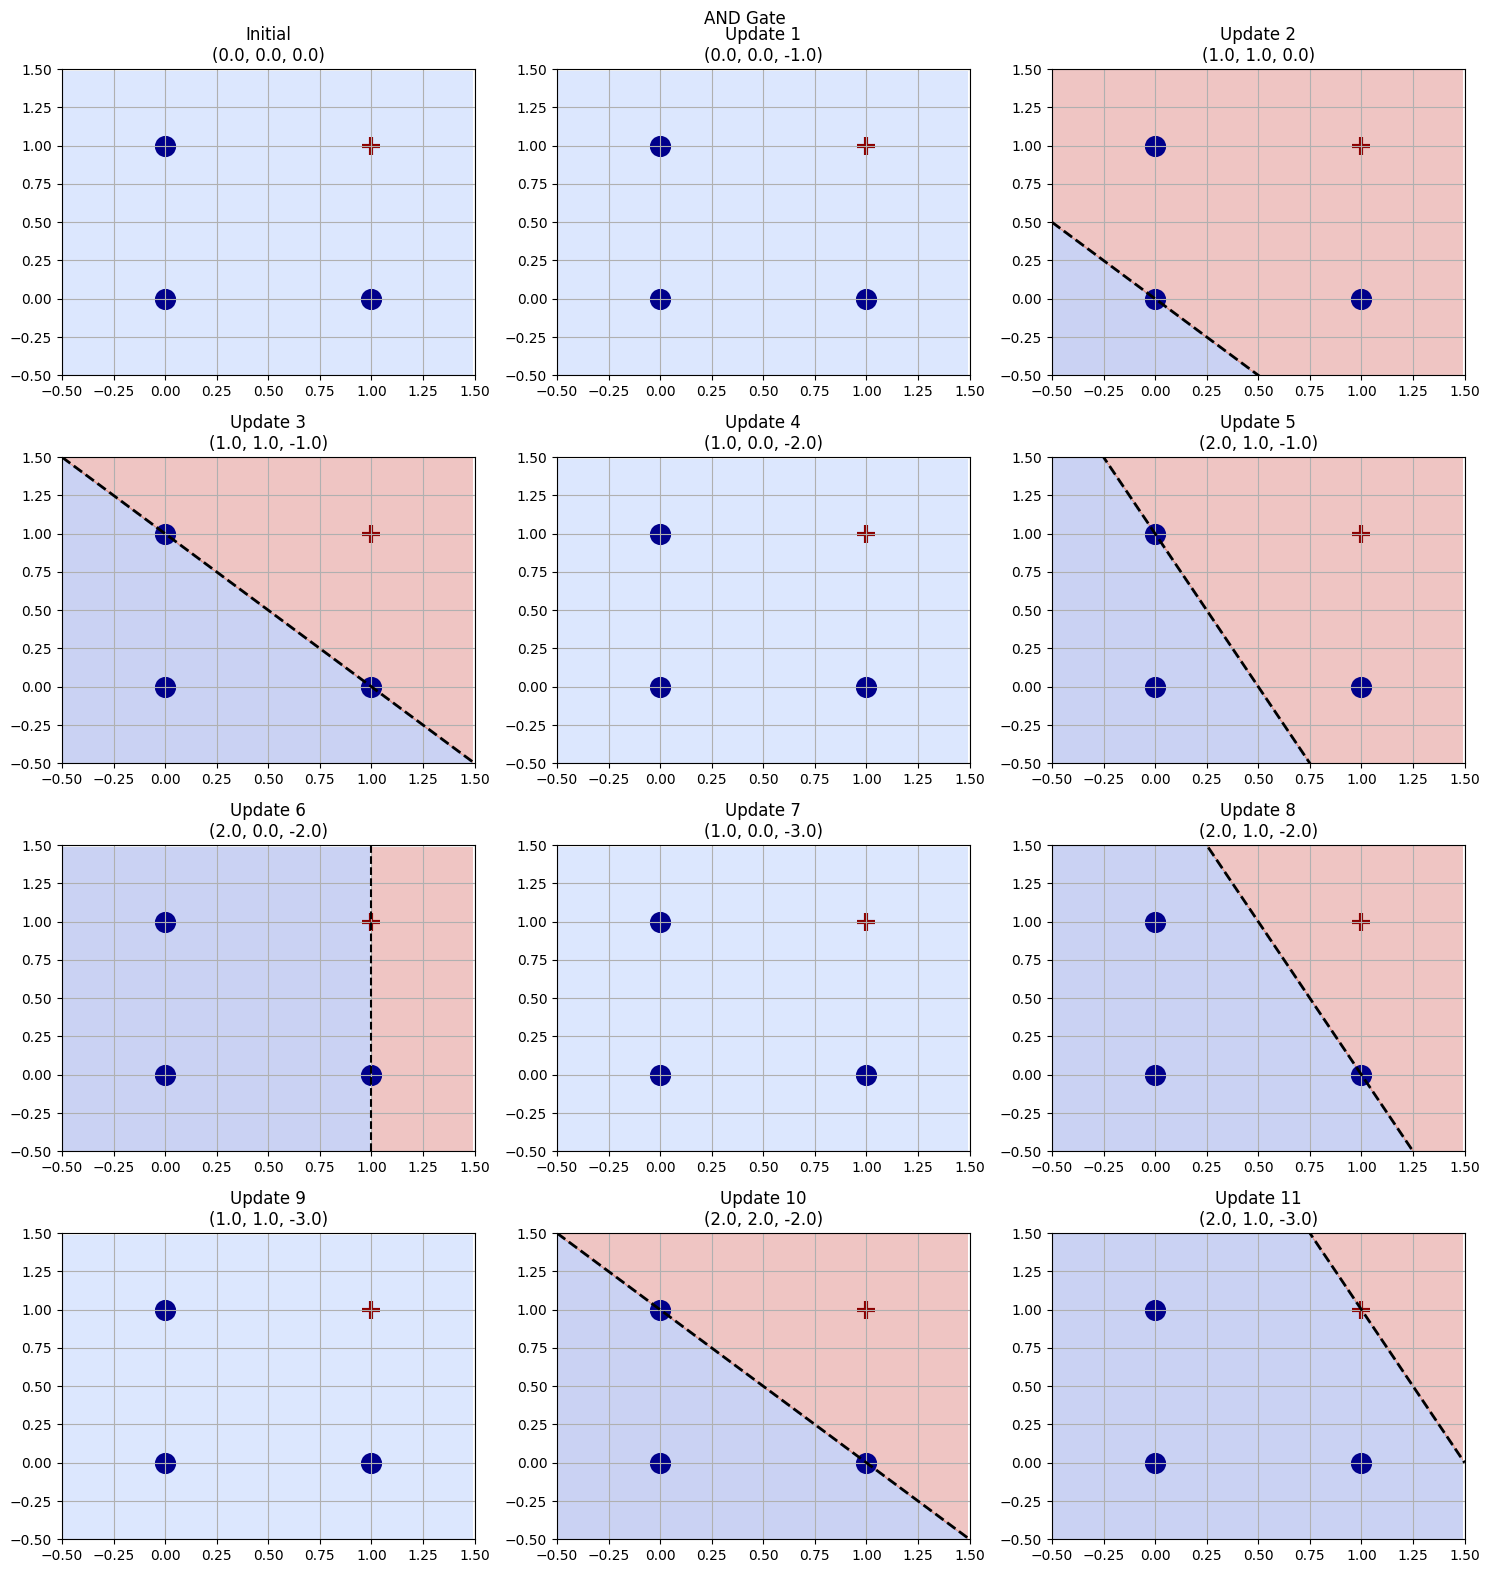

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def step(x):
    return 1 if x >= 0 else 0


#NOT
def plot_1d_subplots(states, X_data, Y_data, gate_name):
    n = len(states)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    x_vals = np.linspace(-0.5, 1.5, 200)

    for ax, (w, b, title) in zip(axes, states):
        y_vals = [step(w * x + b) for x in x_vals]
        ax.plot(x_vals, y_vals, color="blue", linewidth=2)

        for i in range(len(X_data)):
            color = "green" if Y_data[i] == 1 else "red"
            ax.scatter(
                X_data[i][0],
                Y_data[i],
                color=color,
                edgecolor="black",
                s=100,
            )

        ax.set_title(f"{title}\nw={w:.1f}, b={b:.1f}")
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.2, 1.2)
        ax.grid(True)

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(f"{gate_name} Gate")
    plt.tight_layout()

    # Save the figure as an EPS file before displaying it
    filename = f"{gate_name}_gate.eps"
    plt.savefig(filename, format="eps", bbox_inches="tight")
    print(f"Saved plot to {filename}")

    plt.show()

#AND and OR
def plot_2d_subplots(states, X_data, Y_data, gate_name):
    n = len(states)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01),
    )

    for ax, (w1, w2, b, title) in zip(axes, states):
        Z = np.array(
            [
                step(w1 * x + w2 * y + b)
                for x, y in np.c_[xx.ravel(), yy.ravel()]
            ]
        )
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

        if w2 != 0:
            x_line = np.array([x_min, x_max])
            y_line = -(w1 * x_line + b) / w2
            ax.plot(x_line, y_line, "k--", linewidth=2)
        elif w1 != 0:
            ax.axvline(-b / w1, linestyle="--", color="black")

        for i in range(len(X_data)):
            marker = "+" if Y_data[i] == 1 else "o"
            color = "darkred" if Y_data[i] == 1 else "darkblue"

            ax.scatter(
                X_data[i][0],
                X_data[i][1],
                marker=marker,
                color=color,
                s=150,
                linewidths=3,
            )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title(f"{title}\n({w1:.1f}, {w2:.1f}, {b:.1f})")
        ax.grid(True)

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(f"{gate_name} Gate")
    plt.tight_layout()

    filename = f"{gate_name}_gate.eps"
    plt.savefig(filename, format="eps", bbox_inches="tight")
    print(f"Saved plot to {filename}")

    plt.show()


# Training NOT
def train_1d_gate(gate_name, X, Y, lr=1.0):
    print(f"\n========== {gate_name} Gate ==========")
    w = 0.0
    b = 0.0
    max_epochs = 10
    updates = 0

    states = []
    states.append((w, b, "Initial"))

    for epoch in range(max_epochs):
        error_count = 0
        for i in range(len(X)):
            x = X[i][0]
            y_pred = step(w * x + b)

            if y_pred != Y[i]:
                error = Y[i] - y_pred
                w += lr * error * x
                b += lr * error

                updates += 1
                error_count += 1

                print(f"Update {updates}: w={w:.1f}, b={b:.1f}")
                states.append((w, b, f"Update {updates}"))

        if error_count == 0:
            print(f"Converged in {epoch+1} epochs.")
            break

    plot_1d_subplots(states, X, Y, gate_name)

#Training AND and OR
def train_2d_gate(gate_name, X, Y, lr=1.0):
    print(f"\n========== {gate_name} Gate ==========")
    w1 = 0.0
    w2 = 0.0
    b = 0.0
    max_epochs = 10
    updates = 0

    states = []
    states.append((w1, w2, b, "Initial"))

    for epoch in range(max_epochs):
        error_count = 0
        for i in range(len(X)):
            x1, x2 = X[i]
            y_pred = step(w1 * x1 + w2 * x2 + b)

            if y_pred != Y[i]:
                error = Y[i] - y_pred
                w1 += lr * error * x1
                w2 += lr * error * x2
                b += lr * error

                updates += 1
                error_count += 1

                print(
                    f"Update {updates}: w1={w1:.1f}, w2={w2:.1f}, b={b:.1f}"
                )
                states.append((w1, w2, b, f"Update {updates}"))

        if error_count == 0:
            print(f"Converged in {epoch+1} epochs.")
            break

    plot_2d_subplots(states, X, Y, gate_name)



if __name__ == "__main__":
    # NOT
    X_not = [[0], [1]]
    Y_not = [1, 0]
    train_1d_gate("NOT", X_not, Y_not)

    # OR
    X = [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
    ]
    Y_or = [0, 1, 1, 1]
    train_2d_gate("OR", X, Y_or)

    # AND
    Y_and = [0, 0, 0, 1]
    train_2d_gate("AND", X, Y_and)

## For combining all histograms in one subplot for .eps conversion

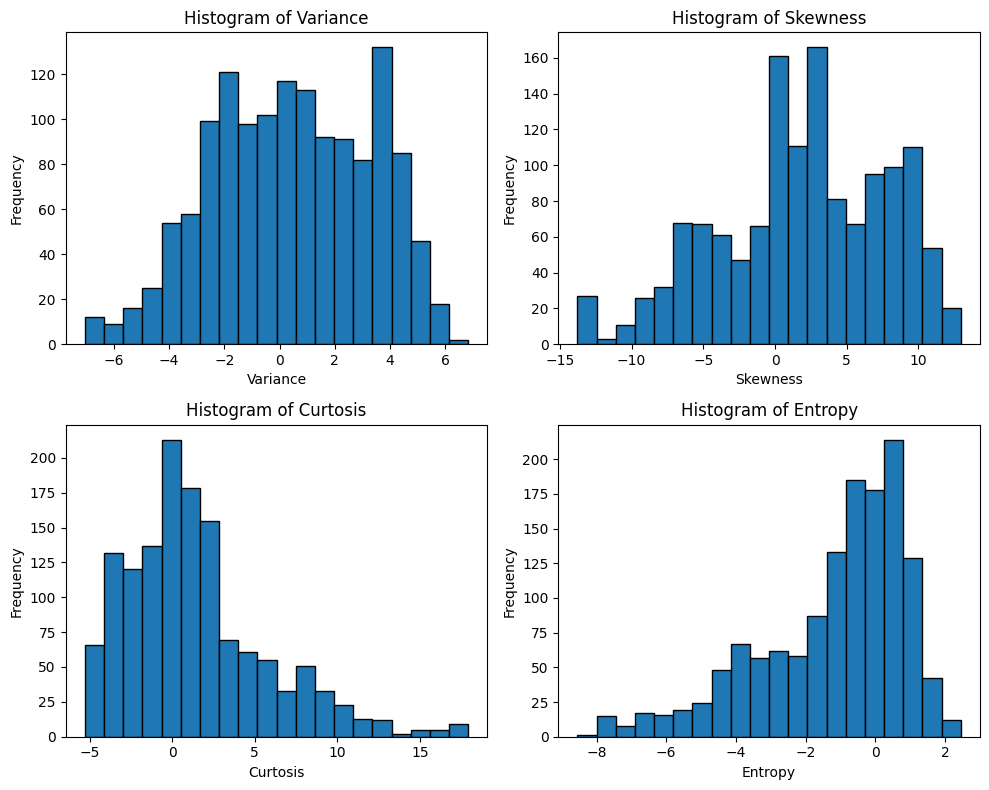

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
cols = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]
df = pd.read_csv(url, names=cols)

plt.rcParams['legend.fontsize'] = 15
features_to_plot = df.drop('Class', axis=1).columns

# 2x2 subplot grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()

# histogram filling in subplots
for i, feature in enumerate(features_to_plot):
    df[feature].hist(bins=20, edgecolor='black', ax=axes[i])
    axes[i].set_title(f'Histogram of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(False) # Remove gridlines

# single .eps file
plt.tight_layout()
plt.savefig('feature_histograms_combined.eps', format='eps', dpi=600)
plt.show()